In [1]:
import pandas as pd
import keras
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
import numpy as np

In [3]:
# Load dataset
data = pd.read_csv('GestureDataset_110x110x3.csv', header=None)

# Separate labels and features
Y = data.iloc[:, 0].values
X = data.iloc[:, 1:].values

# Normalize pixel values
sc = MinMaxScaler()
X = sc.fit_transform(X)

# Encode labels (for multi-class classification)
encoder = LabelEncoder()
Y = encoder.fit_transform(Y)
num_classes = len(np.unique(Y))
Y = to_categorical(Y, num_classes)

# Split dataset
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

In [4]:
# ANN model
NNmodel = Sequential()
NNmodel.add(Dense(512, activation='relu', input_shape=(X_train.shape[1],)))
NNmodel.add(Dense(256, activation='relu'))
NNmodel.add(Dense(num_classes, activation='softmax'))

# Compile model
opt = keras.optimizers.SGD(learning_rate=0.01)
NNmodel.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

c:\Python\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
# Train model
history = NNmodel.fit(X_train, Y_train, epochs=25, batch_size=64, verbose=1, validation_data=(X_test, Y_test))

Epoch 1/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - accuracy: 0.3554 - loss: 1.8972 - val_accuracy: 0.3950 - val_loss: 1.1624
Epoch 2/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.3862 - loss: 1.0887 - val_accuracy: 0.4050 - val_loss: 1.0678
Epoch 3/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.4338 - loss: 1.0710 - val_accuracy: 0.3983 - val_loss: 1.0705
Epoch 4/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - accuracy: 0.4592 - loss: 1.0361 - val_accuracy: 0.4333 - val_loss: 1.0318
Epoch 5/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - accuracy: 0.4846 - loss: 1.0086 - val_accuracy: 0.4133 - val_loss: 1.0377
Epoch 6/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.5113 - loss: 0.9848 - val_accuracy: 0.4100 - val_loss: 1.0717
Epoch 7/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.5333 - loss: 0.9627 - val_accuracy: 0.4867 - val_loss: 0.9829
Epoch 8/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.5533 - loss: 0.9232 - val_accuracy: 0.468

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7017 - loss: 0.6769
Loss of test set = 0.6769472360610962
Accuracy of test set = 0.7016666531562805


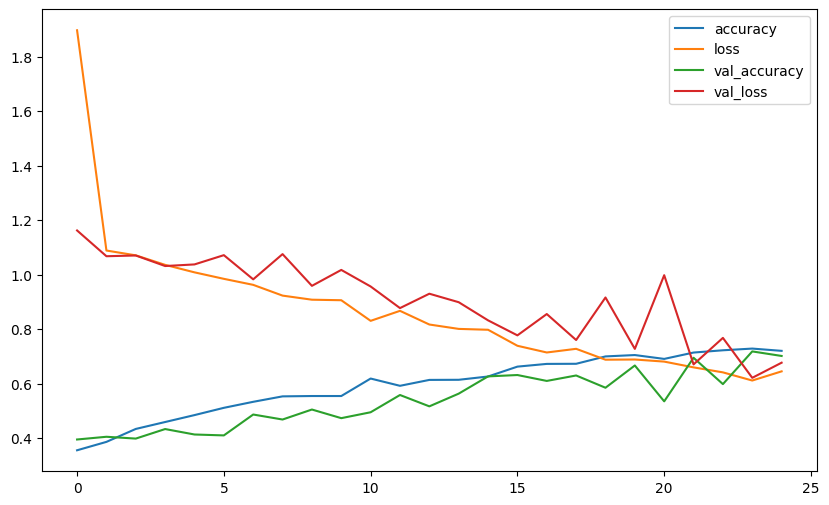

In [6]:
# Evaluate
result = NNmodel.evaluate(X_test, Y_test)
print("Loss of test set =", result[0])
print("Accuracy of test set =", result[1])

# Plot training history
pd.DataFrame(history.history).plot(figsize=(10,6))
plt.show()